# AM01 Pre-course assignment



**Name:**

**Email:**

**Date:**

## Task 1: Short bio written using markdown


(Write your bio here, using markdown features: headers, bold, lists, links to LinkedIn and social media, images, etc.)

My bio.....

## Task 2: gapminder country comparison

The `gapminder` dataset that has data on life expectancy, population, and GDP per capita for 142 countries from 1952 to 2007. To get a glimpse of the dataframe, namely to see the variable names, variable types, etc., we use the `info()` and `head()` functions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gapminder = pd.read_csv(
    "https://raw.githubusercontent.com/jennybc/gapminder/main/data-raw/08_gap-every-five-years.tsv",
    sep="\t"
)

gapminder.info()
gapminder.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
5,Afghanistan,Asia,1977,38.438,14880372,786.113360
6,Afghanistan,Asia,1982,39.854,12881816,978.011439
7,Afghanistan,Asia,1987,40.822,13867957,852.395945
8,Afghanistan,Asia,1992,41.674,16317921,649.341395
9,Afghanistan,Asia,1997,41.763,22227415,635.341351


### Filter for your country and continent (example: Greece, Europe)


In the code below change to your country- continent. Unfortunately, not all countries are listed, so if your country doesnt show up, just choose any other country you like, or just leave Greece, which I hear is not a bad place :-) 

In [4]:
country_data = gapminder[gapminder['country'] == 'Greece']
continent_data = gapminder[gapminder['continent'] == 'Europe']

### Plot life expectancy over time for your country


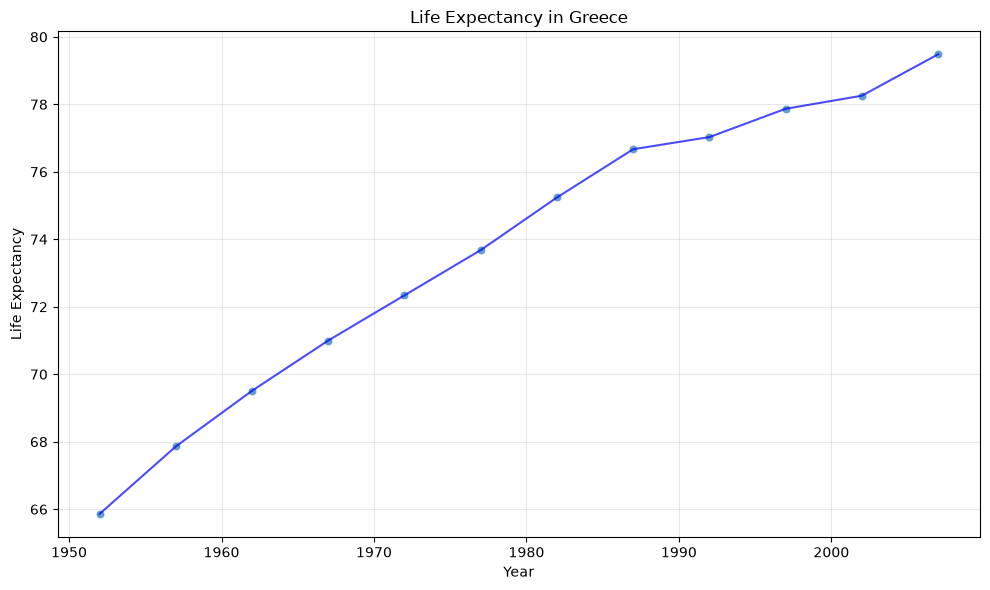

In [5]:
plt.figure(figsize=(10, 6))                # Create a new figure with a specific size (10x6 inches)

# Scatter plot with regression line (without regression fit, just line connection)
sns.scatterplot(
    data=country_data,                     # Use the 'country_data' DataFrame as the data source
    x='year',                              # Plot 'year' on the x-axis
    y='lifeExp',                           # Plot 'lifeExp' (life expectancy) on the y-axis
    alpha=0.7                              # Make the scatter points slightly transparent (70% opaque)
)
sns.lineplot(
    data=country_data,                     # Use the same data to draw a line through data points
    x='year',
    y='lifeExp',
    color='b',                             # Line color blue ('b')
    alpha=0.7                              # Make the line slightly transparent
)

plt.title('Life Expectancy in Greece')     # Set the title of the plot
plt.xlabel('Year')                          # Label the x-axis as 'Year'
plt.ylabel('Life Expectancy')               # Label the y-axis as 'Life Expectancy'
plt.grid(True, alpha=0.3)                   # Add a light grid to the background for readability
plt.tight_layout()                          # Adjust plot layout to prevent overlapping elements
plt.show()                                 # Display the plot


### Plot life expectancy over time for all countries in your continent (colour by country)

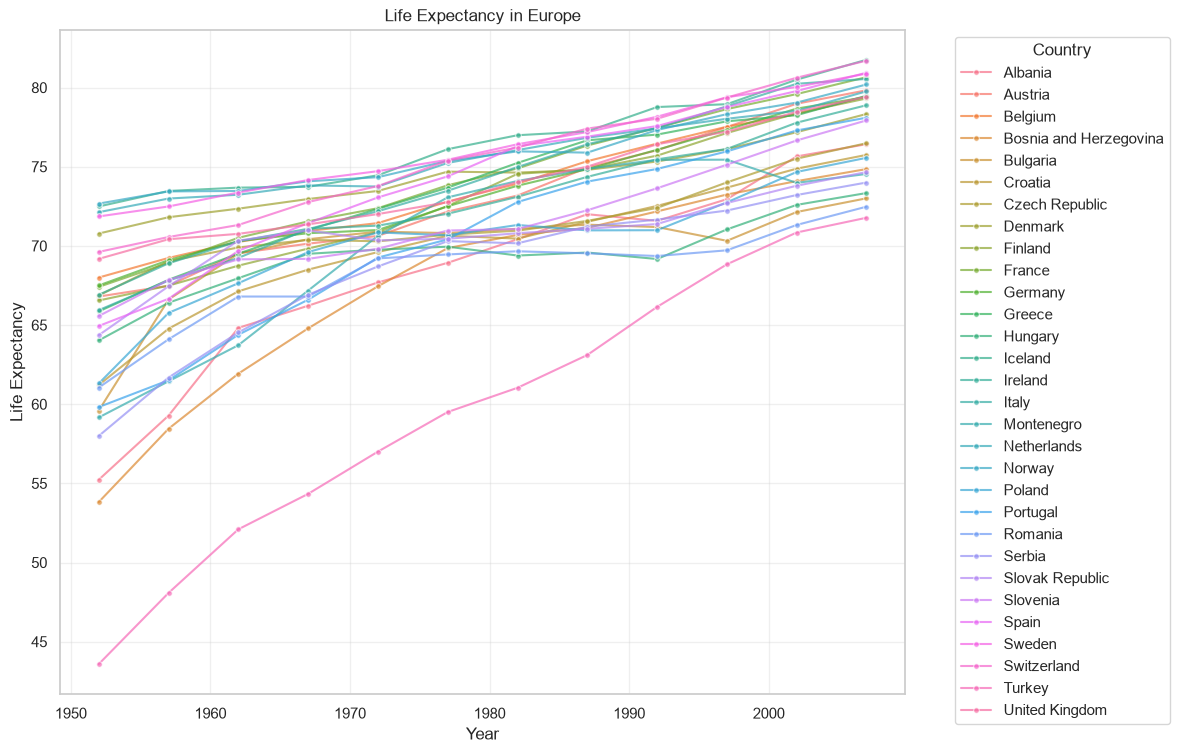

In [6]:
# Set a theme for consistent styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Create a Seaborn line plot showing life expectancy over years for each country in the continent
sns.lineplot(
    data=continent_data,          # The DataFrame with data for the selected continent
    x="year",                     # X-axis: year
    y="lifeExp",                  # Y-axis: life expectancy
    hue="country",                # Color each line by country
    marker="o",                   # Add circular markers at each data point
    linewidth=1.5,                # Set line width for better visibility
    alpha=0.7,                    # Set transparency: 0 (transparent) to 1 (opaque)
    markersize=4                  # Size of the markers on each data point
)

# Add a plot title
plt.title("Life Expectancy in Europe")

# Label the X-axis
plt.xlabel("Year")

# Label the Y-axis
plt.ylabel("Life Expectancy")

# Move the legend outside the main plot for readability; label it "Country"
plt.legend(bbox_to_anchor=(1.05, 1), 
           loc="upper left", 
           title="Country")

# Add a light grid for easier reading of values
plt.grid(True, alpha=0.3)

# Adjust spacing to prevent overlap of plot elements
plt.tight_layout()

# Display the plot
plt.show()


### Life expectancy over time, faceted by continent (no legend)

<Figure size 1200x800 with 0 Axes>

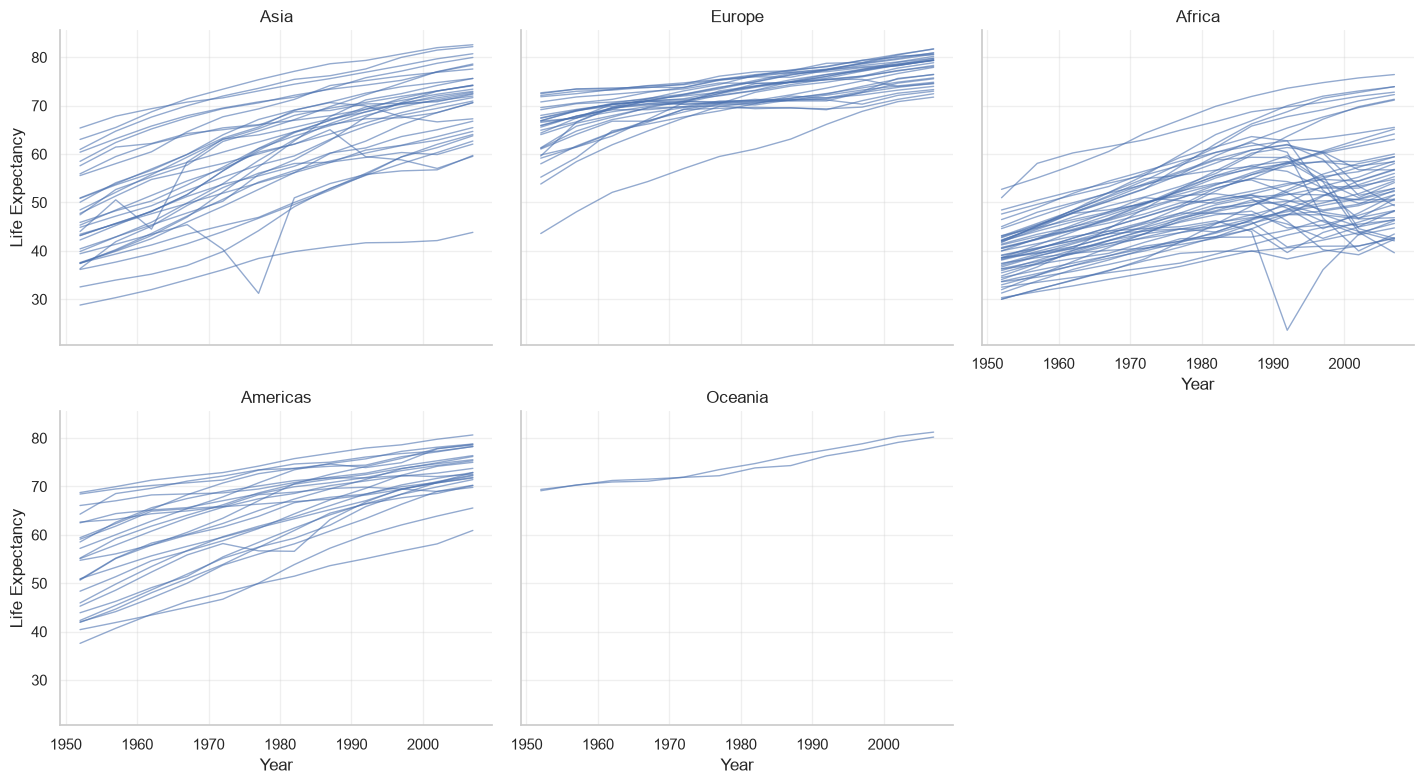

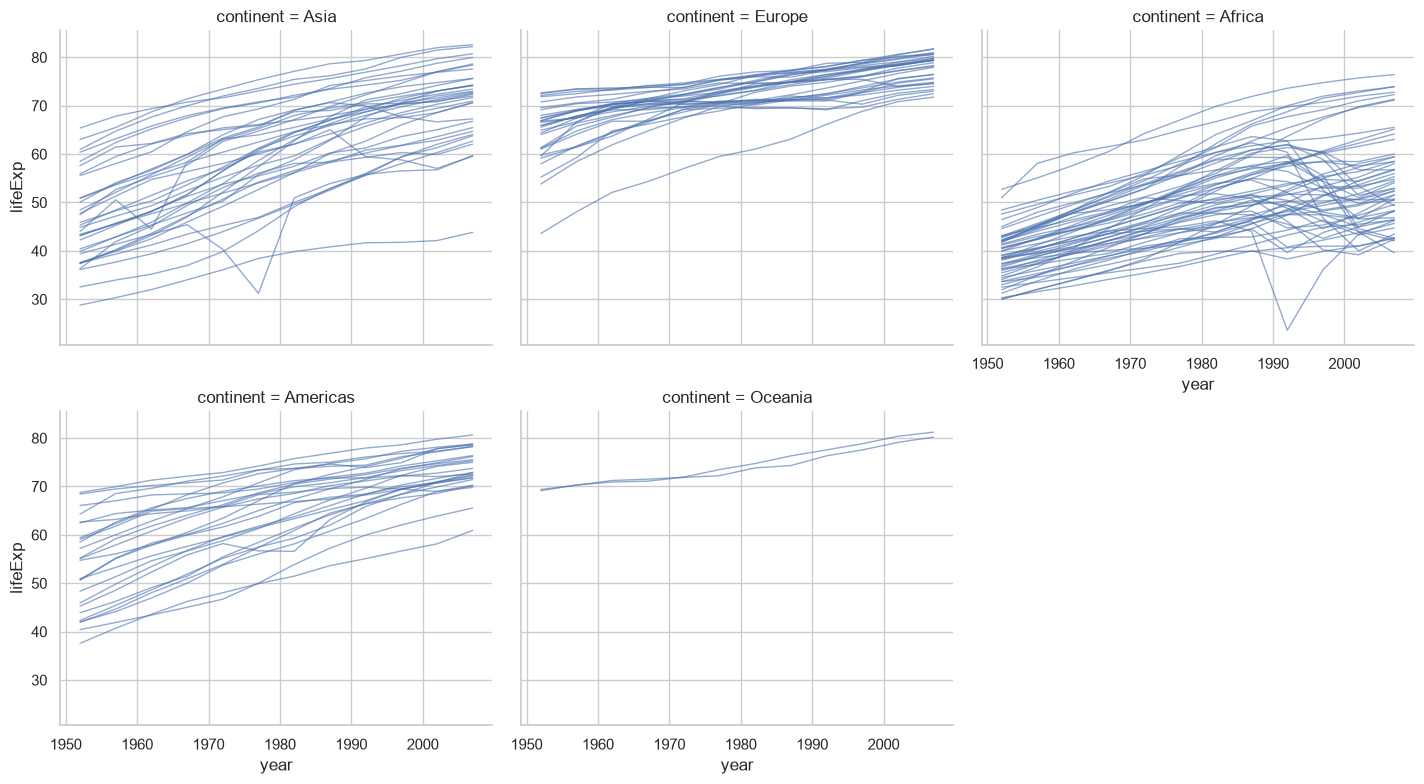

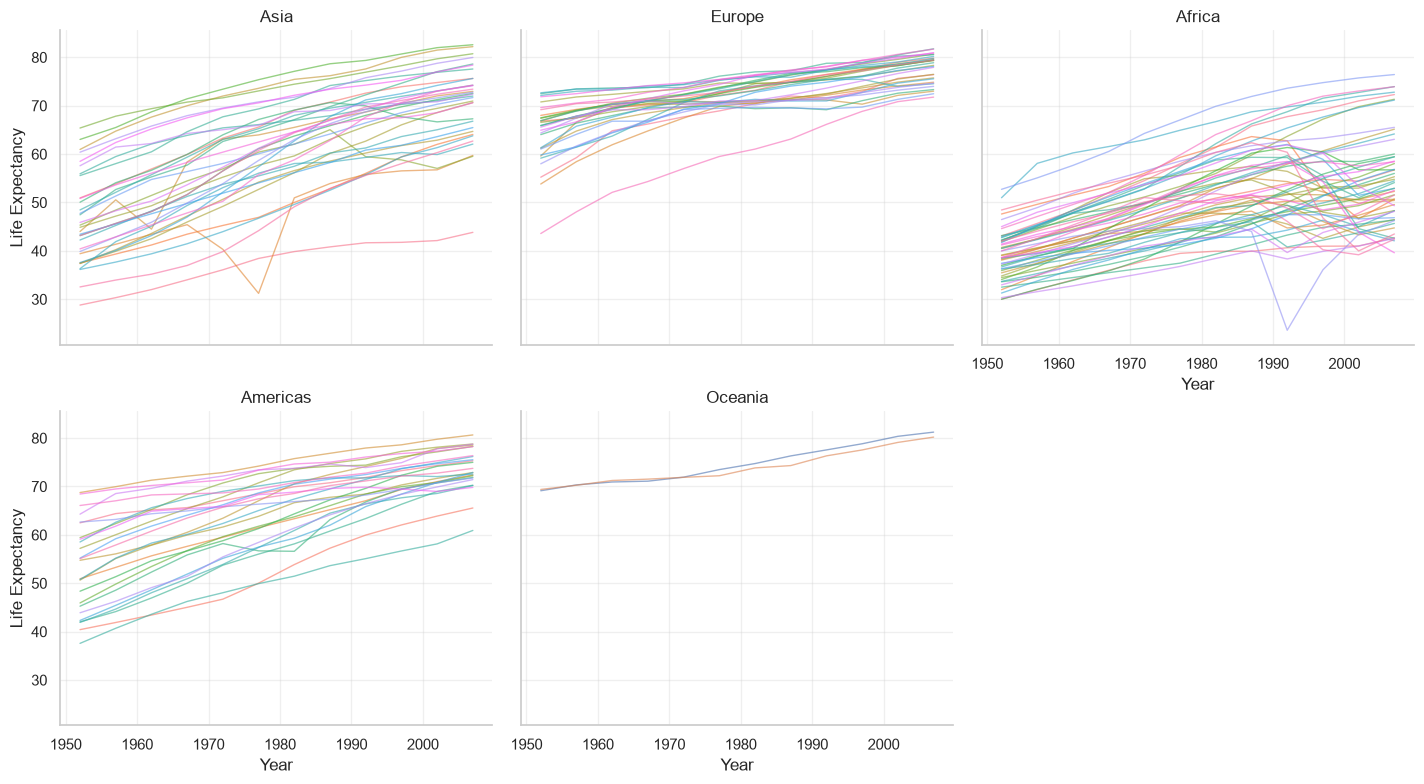

In [7]:
# Set a theme for consistent styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))


# Method 1: Using FacetGrid (most flexible)

# Create a FacetGrid: make a grid of plots, one for each continent
g = sns.FacetGrid(
    gapminder,                  # DataFrame containing all data
    col='continent',            # Each facet (subplot) represents a continent
    col_wrap=3,                 # Wrap subplots in rows of 3
    height=4,                   # Height of each subplot in inches
    aspect=1.2                  # Aspect ratio (width = 1.2 * height)
)

# Map a lineplot onto each facet
g.map_dataframe(
    sns.lineplot,               # Use Seaborn's lineplot function
    x='year',                   # x-axis: year
    y='lifeExp',                # y-axis: life expectancy
    units='country',            # Group lines by country (keeps separate lines per country)
    estimator=None,             # Plot each country's actual line without aggregation
    alpha=0.6,                  # Set line transparency
    linewidth=1                 # Set line thickness
)

# Set the title for each facet (subplot) to the continent name
g.set_titles('{col_name}')

# Set shared axis labels for all facets
g.set_axis_labels('Year', 'Life Expectancy')

# Add a light grid to every subplot for readability
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)

# Adjust subplot spacing to avoid overlap
plt.tight_layout()

# Display all the facets (plots)
plt.show()


# Method 2: Using relplot (more concise code)
# Create a multi-facet line plot of life expectancy vs. year, split by continent
sns.relplot(
    data=gapminder,                  # Data source: Gapminder DataFrame
    x='year',                        # X-axis: year
    y='lifeExp',                     # Y-axis: life expectancy
    col='continent',                 # Separate subplot for each continent
    col_wrap=3,                      # Maximum 3 plots per row, wrap into new rows as needed
    kind='line',                     # Plot type: line plot
    units='country',                 # Draw separate lines for each country
    estimator=None,                  # Do not aggregate data; plot raw data for each country
    alpha=0.6,                       # Set transparency of lines to 60% for overlapping visibility
    linewidth=1,                     # Set line thickness
    height=4,                        # Subplot height in inches
    aspect=1.2                       # Subplot width is 1.2 times the height
)

# Display the resulting plots
plt.show()



# Method 3: If you want to highlight individual countries differently

# Create a FacetGrid: a grid of plots for each continent, customizing the layout and size
g = sns.FacetGrid(
    gapminder,                 # Data source: Gapminder DataFrame
    col='continent',           # Split the grid by 'continent', making a subplot for each
    col_wrap=3,                # Wrap facets in rows of 3 plots each
    height=4,                  # Each subplot will be 4 inches tall
    aspect=1.2                 # Each subplot's width will be 1.2 times its height
)

# Map a colored lineplot onto each facet, using 'country' as hue to color lines by country
g.map_dataframe(
    sns.lineplot,              # Specify lineplot as the plotting function
    x='year',                  # X-axis: years
    y='lifeExp',               # Y-axis: life expectancy
    hue='country',             # Color each country's line differently within each subplot
    legend=False,              # Do not display the legend (avoids clutter with many countries)
    alpha=0.6,                 # Make lines partially transparent for easier viewing of overlap
    linewidth=1                # Set thin lines for clarity with many lines
)

# Customize axis and subplot titles and labels
g.set_titles('{col_name}')             # Title each subplot with the continent name
g.set_axis_labels('Year', 'Life Expectancy')  # Set common axis labels

# Add a light grid to every subplot to improve readability
for ax in g.axes.flat:
    ax.grid(True, alpha=0.3)           # Enable grid with low transparency

# Adjust subplot spacing for a neat appearance
plt.tight_layout()

# Display the final multi-panel, colored line plots
plt.show()







Given these trends, what can you say about life expectancy since 1952? Again, don't just say what's happening in the graph. Tell some sort of story and speculate about the differences in the patterns. Type your answer below.

## Task 3: The `nycflights13` package

The `nycflights13` package contains data for all domestic flights departing out of New York's three airports (JFK, EWR, LGA) in 2013. Also includes useful 'metadata' on airlines, airports, weather, and planes.



In [3]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")
import nycflights13 as nf


import nycflights13 as nf   # Data exist in `nycflights13` 
flights = nf.flights        # different tables in the database
weather = nf.weather
airlines = nf.airlines
airports = nf.airports
planes = nf.planes

In [84]:
# how many rows and columns (variables) does `flights` have

# how many carriers does `airlines` have? How many airports are there? and how many different airplanes does `planes` have data on?

# please answer below 

**Data Summary**

`flights` has ....

`airlines` has data on XXX carriers  

How many airports are there? 

How many different airplanes does `planes` have data on?

### Problem 1: Use logical operators and the flights table to find flights that...

In [85]:
# Had an arrival delay of two or more hours (arr_delay > 120 minutes)
flights[flights['arr_delay'] > 120]

# Please sort the table in descending order of arr_delay


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
119,2013,1,1,811.0,630,101.0,1047.0,830,137.0,MQ,4576,N531MQ,LGA,CLT,118.0,544,6,30,2013-01-01T11:00:00Z
151,2013,1,1,848.0,1835,853.0,1001.0,1950,851.0,MQ,3944,N942MQ,JFK,BWI,41.0,184,18,35,2013-01-01T23:00:00Z
218,2013,1,1,957.0,733,144.0,1056.0,853,123.0,UA,856,N534UA,EWR,BOS,37.0,200,7,33,2013-01-01T12:00:00Z
268,2013,1,1,1114.0,900,134.0,1447.0,1222,145.0,UA,1086,N76502,LGA,IAH,248.0,1416,9,0,2013-01-01T14:00:00Z
447,2013,1,1,1505.0,1310,115.0,1638.0,1431,127.0,EV,4497,N17984,EWR,RIC,63.0,277,13,10,2013-01-01T18:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336579,2013,9,30,1823.0,1545,158.0,1934.0,1733,121.0,9E,3459,N916XJ,JFK,BNA,95.0,765,15,45,2013-09-30T19:00:00Z
336668,2013,9,30,1951.0,1649,182.0,2157.0,1903,174.0,EV,4294,N13988,EWR,SAV,95.0,708,16,49,2013-09-30T20:00:00Z
336724,2013,9,30,2053.0,1815,158.0,2310.0,2054,136.0,EV,5292,N600QX,EWR,ATL,91.0,746,18,15,2013-09-30T22:00:00Z
336757,2013,9,30,2159.0,1845,194.0,2344.0,2030,194.0,9E,3320,N906XJ,JFK,BUF,50.0,301,18,45,2013-09-30T22:00:00Z


In [86]:
# Flew to Houston, namely dest is IAH or HOU
flights[flights['dest'].isin(['IAH', 'HOU'])]

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
32,2013,1,1,623.0,627,-4.0,933.0,932,1.0,UA,496,N459UA,LGA,IAH,229.0,1416,6,27,2013-01-01T11:00:00Z
81,2013,1,1,728.0,732,-4.0,1041.0,1038,3.0,UA,473,N488UA,LGA,IAH,238.0,1416,7,32,2013-01-01T12:00:00Z
89,2013,1,1,739.0,739,0.0,1104.0,1038,26.0,UA,1479,N37408,EWR,IAH,249.0,1400,7,39,2013-01-01T12:00:00Z
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336524,2013,9,30,1729.0,1720,9.0,2001.0,2010,-9.0,UA,652,N455UA,EWR,IAH,173.0,1400,17,20,2013-09-30T21:00:00Z
336527,2013,9,30,1735.0,1715,20.0,2010.0,2005,5.0,WN,2067,N296WN,EWR,HOU,188.0,1411,17,15,2013-09-30T21:00:00Z
336618,2013,9,30,1859.0,1859,0.0,2134.0,2159,-25.0,UA,1128,N14731,LGA,IAH,180.0,1416,18,59,2013-09-30T22:00:00Z
336694,2013,9,30,2015.0,2015,0.0,2244.0,2307,-23.0,UA,1545,N17730,EWR,IAH,174.0,1400,20,15,2013-10-01T00:00:00Z


In [87]:
# Were operated by 'carrier'  United (UA), American (AA), or Delta (DL)


In [88]:
# Departed in summer (July, August, and September) or month == 7, 8, 9


### Problem 2: Weather table analysis

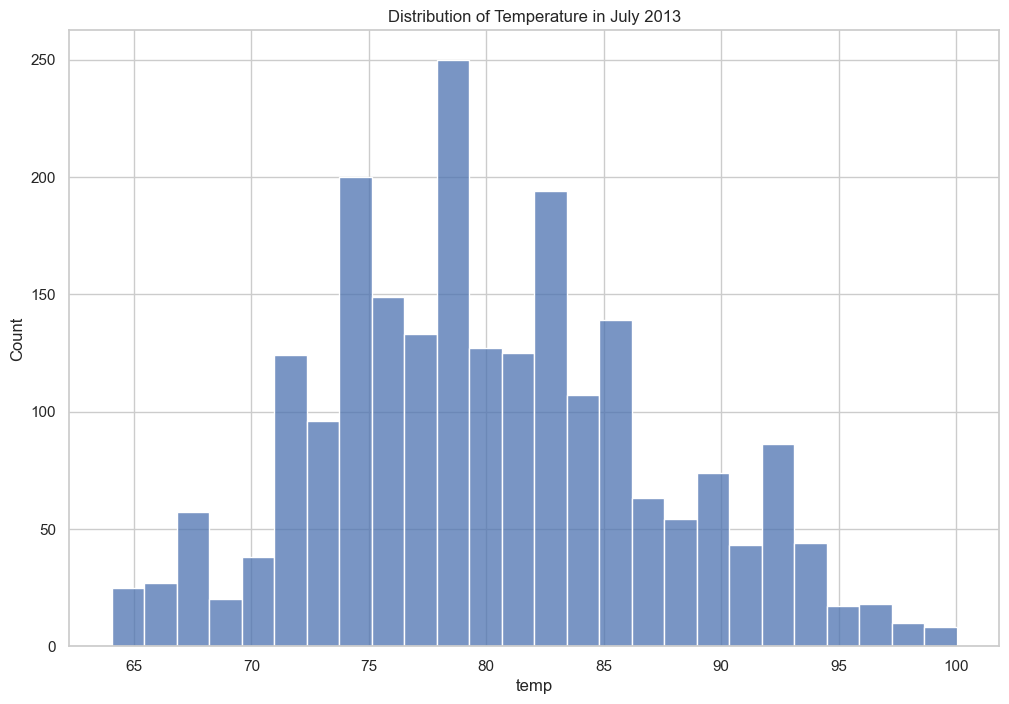

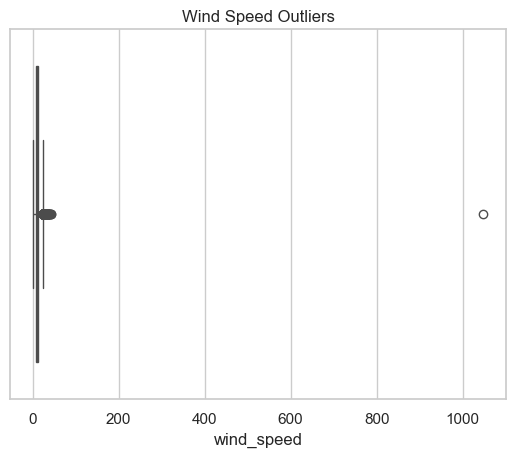

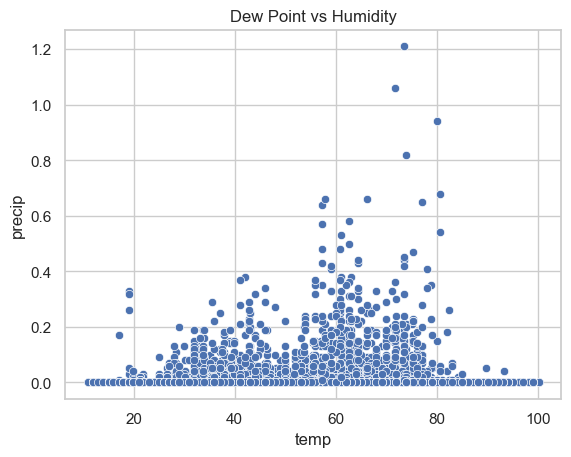

In [89]:
# Set a theme for consistent styling
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Distribution of temperature in July 2013 - use a histogram
sns.histplot(weather[weather['month'] == 7]['temp'])
plt.title('Distribution of Temperature in July 2013')
plt.show()

# Outliers in wind_speed - try a boxplot
sns.boxplot(x=weather['wind_speed'])
plt.title('Wind Speed Outliers')
plt.show()

# Relationship between temp and precip. temp on the x-axis, precip on y
sns.scatterplot(x='temp', y='precip', data=weather)
plt.title('Dew Point vs Humidity')
plt.show()


> What do you observe from these three graphs? What is the key takeway from each of them? Write a couple of sentences below for each of them.

Plot 1:

Plot 2:

Plot 3:

### Problem 3: Arrival delays

In [90]:
# Median arr_delay by month and origin
flights.groupby(['month', 'origin'])['arr_delay'].median().unstack()



origin,EWR,JFK,LGA
month,,,
1,0.0,-7.0,-4.0
2,-2.0,-5.0,-4.0
3,-4.0,-7.0,-7.0
4,-1.0,-4.0,-2.0
5,-6.0,-9.0,-9.0
6,-1.0,-1.0,-4.0
7,-2.0,1.0,-3.0
8,-5.0,-5.0,-6.0
9,-13.0,-12.0,-12.0


Can you determine which month is worse for flying? What about using the mean instead of the median? Or `dep_delay` instead of `arr_delay`? Write a couple of pragrpahs with your thoughts- findings

In [91]:
# Compute stats (mean, median, min, max, std) on arr_delay by dest, and sort them in desceding order of median arr_delay




In [92]:
# Compute stats on arr_delay by carrier, sorted by median arr_delay in descending order and save them to an object called carrier_delays



carrier_delays


# the code below makes the table more user friendly, so instead of carrioer = DL, you get its name, Delta Airlines
# We need to join `carrier_delays` with the `airlines`` table to get names - this is like a SQL left join
delays_named = carrier_delays.merge(airlines, 
    on='carrier', 
    how='left')

# Arrange columns for readability
delays_named = delays_named[['carrier', 'name', 'mean', 'median', 'std', 'min', 'max']]
delays_named

,carrier,name,mean,median,std,min,max
0,F9,Frontier Airlines Inc.,21.920705,6.0,61.645997,-47.0,834.0
1,FL,AirTran Airways Corporation,20.115906,5.0,54.087671,-44.0,572.0
2,EV,ExpressJet Airlines Inc.,15.796431,-1.0,49.861469,-62.0,577.0
3,MQ,Envoy Air,10.774733,-1.0,43.174306,-53.0,1127.0
4,YV,Mesa Airlines Inc.,15.556985,-2.0,52.922234,-46.0,381.0
5,B6,JetBlue Airways,9.457973,-3.0,42.842297,-71.0,497.0
6,WN,Southwest Airlines Co.,9.649120,-3.0,46.877702,-58.0,453.0
7,UA,United Air Lines Inc.,3.558011,-6.0,40.984344,-75.0,455.0
8,US,US Airways Inc.,2.129595,-6.0,33.066952,-70.0,492.0
9,9E,Endeavor Air Inc.,7.379669,-7.0,50.086778,-68.0,744.0


## Details
- Who did you collaborate with: TYPE NAMES HERE
- Approximately how much time did you spend on this problem set: ANSWER HERE
- What, if anything, gave you the most trouble: ANSWER HERE